<a href="https://colab.research.google.com/github/richirey75/Data-Mining-CS4990/blob/Prernas-Assignment-4-Branch/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
combined_dfForFPA = pd.read_csv('combined_tracks_info_ArijitSingh_KK.csv')

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Seeing how the libraries output stuff

In [19]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules

# Load the Spotify dataset (assuming 'energy', 'valence', and 'danceability' columns exist)
spotify_data = combined_dfForFPA

# 1. Discretize 'energy', 'valence', and 'danceability' into 'Low', 'Medium', 'High'
# This categorizes each feature into 3 bins: low, medium, and high
def categorize_feature(feature_column, num_bins=3):
    categories = ['Low', 'Medium', 'High']
    return pd.cut(feature_column, bins=num_bins, labels=categories)

# Apply the discretization function to the relevant features
spotify_data['energy_category'] = categorize_feature(spotify_data['energy'])
spotify_data['valence_category'] = categorize_feature(spotify_data['valence'])
spotify_data['danceability_category'] = categorize_feature(spotify_data['danceability'])

# 2. Convert the categorized features into one-hot encoded DataFrame
# This is necessary for the Apriori algorithm
one_hot_encoded_data = pd.get_dummies(spotify_data[['energy_category', 'valence_category', 'danceability_category']])

# 3. Apply the Apriori algorithm to discover frequent itemsets
# min_support defines the minimum threshold for an itemset to be considered frequent
frequent_itemsets = apriori(one_hot_encoded_data, min_support=0.1, use_colnames=True)

# 4. Generate association rules from the discovered frequent itemsets
# Get the number of itemsets from the original DataFrame
num_itemsets = len(spotify_data)
association_rules_df = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5, num_itemsets=num_itemsets)

# 5. Sort the rules by 'lift' to find the most interesting or impactful ones
sorted_rules = association_rules_df.sort_values(by='lift', ascending=False)

# 6. Display the most relevant columns of the association rules DataFrame
print(sorted_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])



                                          antecedents  \
18  (energy_category_High, danceability_category_H...   
4                             (valence_category_High)   
9                             (valence_category_High)   
19  (valence_category_High, danceability_category_...   
17      (energy_category_High, valence_category_High)   
10  (danceability_category_Medium, valence_categor...   
16    (energy_category_High, valence_category_Medium)   
0                              (valence_category_Low)   
15  (danceability_category_Medium, energy_category...   
7                      (danceability_category_Medium)   
8                           (valence_category_Medium)   
12  (danceability_category_Medium, energy_category...   
11     (energy_category_Medium, valence_category_Low)   
1                           (valence_category_Medium)   
6                              (valence_category_Low)   
14  (energy_category_Medium, valence_category_Medium)   
2                      (danceab

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


<div class="markdown-google-sans">
  <h1>Welcome to Colab!</h1>
</div>

<div class="markdown-google-sans">
  <h2>Explore the Gemini API</h2>
  <p>The Gemini API gives you access to Gemini models created by Google DeepMind. Gemini models are built from the ground up to be multimodal, so you can reason seamlessly across text, images, code, and audio.
  </p>
  <strong>How to get started</strong>
    <ol>
      <li>Go to <a href="https://aistudio.google.com/">Google AI Studio</a> and log in with your Google account.</li>
      <li><a href="https://aistudio.google.com/app/apikey">Create an API key</a>.</li>
      <li>Use a quickstart for <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Prompting.ipynb">Python</a>, or call the REST API using <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/rest/Prompting_REST.ipynb">curl</a>.</li>
      </ol>
  <strong>Explore use cases</strong>
    <ul>
      <li><a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Market_a_Jet_Backpack.ipynb">Create a marketing campaign</a></li>
      <li><a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Audio.ipynb">Analyze audio recordings</a></li>
      <li><a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/System_instructions.ipynb">Use System instructions in chat</a></li>
    </ul>
  <p>To learn more, check out the <a href="https://github.com/google-gemini/cookbook">Gemini cookbook</a> or visit the <a href="https://ai.google.dev/docs/">Gemini API documentation</a>.
  </p>
</div>


In [30]:
import math
import itertools
from itertools import combinations

# DO NOT CHANGE THE FOLLOWING LINE
def apriori(itemsets, threshold):
    # DO NOT CHANGE THE PRECEDING LINE

    # calculate the minimum support count
    # min_support = (threshold / 100) * len(itemsets)

    # find frequent 1-itemsets
    L = find_frequent_1_itemsets(itemsets, threshold)

    k = 2 # start with 2-itemsets (pairs of items)
    all_freq_items = L.copy()

    while True:
        Ck = apriori_gen(L, k) # generate k-itemsets from frequent (k-1) itemsets

        if not Ck: # no candidates, stop
            break

        # count support of candidate k-itemsets by checking their occurence in the itemsets
        freq_k = []
        for c in Ck:
            count = sum(1 for itemset in itemsets if set(c).issubset(itemset))
            support = count / len (itemsets)
            if support >= threshold:
                freq_k.append((c, support))

        # find frequent k-itemsets, add to L
        if freq_k:
            L = freq_k
            all_freq_items.extend(freq_k)
        else:
            break

        k+=1

    # Should return a list of pairs, where each pair consists of the frequent itemset and its support
    # e.g. [(set(items), 0.7), (set(otheritems), 0.74), ...]
    return [(set(itemset), support) for itemset, support in all_freq_items]

# function to find frequent 1-itemsets
def find_frequent_1_itemsets(itemsets, min_support):
    item_counts = {}
    for itemset in itemsets:
        for item in itemset:
            # count how many times each item appears in the dataset
            if item in item_counts:
                item_counts[item] += 1
            else:
                item_counts[item] = 1
    min_count = min_support * len(itemsets)
    return [(tuple([item]), count / len(itemsets)) for item, count in item_counts.items() if count >= min_count]

# function to generate candidate k-itemsets (k >= 2)
def apriori_gen(Lk_1, k):
    Ck = [] # list to store candidate k-itemsets (Ck)

    # compare every pair of (k-1) itemsets in Lk-1 to generate candidate k-itemsets
    for i in range(len(Lk_1)):
        for j in range(i+1, len(Lk_1)):
            l1, l2 = sorted(Lk_1[i][0]), sorted(Lk_1[j][0])

            if l1[:k-2] == l2[:k-2]:
                c = tuple(sorted(set(Lk_1[i][0]).union(Lk_1[j][0]))) # join two itemsets to form a candidate (c)

                if not has_infrequent_subset(c, Lk_1):
                    Ck.append(c)
    return Ck

# function to check if candidate k-itemset has any infrequent (k-1) itemsets
def has_infrequent_subset(c, Lk_1):
    for subset in combinations(c, len(c) - 1):
        if not any(set(subset) == set(itemset[0]) for itemset in Lk_1):
            return True
    return False

# DO NOT CHANGE THE FOLLOWING LINE
def association_rules(itemsets, frequent_itemsets, metric, metric_threshold):
    # DO NOT CHANGE THE PRECEDING LINE

    # Should return a list of triples: condition, effect, metric value
    # Each entry (c,e,m) represents a rule c => e, with the matric value m
    # Rules should only be included if m is greater than the given threshold.
    # e.g. [(set(condition),set(effect),0.45), ...]

    # initialize rules to be returned as a list
    rules = []

    # for each frequent itemset, generate all nonempty subsets of each frequent itemset
    for (itemset, support) in frequent_itemsets:
        # generate subsets of itemset to be converted into antecedents
        for r in range(1, len(itemset)):
            for subset in itertools.combinations(itemset, r):
                antecedent = set(subset)
                consequent = itemset - antecedent

                #check if consequent is empty
                if not consequent:
                    continue

                # calculate support of antecedent
                antecedent_support = find_support(antecedent, itemsets)

                if antecedent_support == 0:
                    continue;

                # calculate metrics
                confidence = support / antecedent_support
                lift = confidence / find_support(consequent, itemsets)
                kulczynski = 0.5 * (confidence + (support / find_support(consequent, itemsets)))
                cosine = support / math.sqrt(antecedent_support * find_support(consequent, itemsets))
                max_conf = max(confidence, (support / find_support(consequent, itemsets)))
                all_conf = support / max(antecedent_support, find_support(consequent, itemsets))

                # determine if the rule passes the metric threshold
                if metric == "confidence":
                    metric_value = confidence
                elif metric == "lift":
                    metric_value = lift
                elif metric == "all":
                    metric_value = all_conf;
                elif metric == "max":
                    metric_value = max_conf;
                elif metric == "kulczynski":
                    metric_value = kulczynski
                elif metric == "cosine":
                    metric_value = cosine

                if metric_value >= metric_threshold:
                    rules.append((set(antecedent), set(consequent), metric_value))
    return rules

# calculate support, represented as a percentage
def find_support(antecedent, itemsets):
    count = sum(1 for itemset in itemsets if set(antecedent).issubset(itemset))
    support = count / len(itemsets)
    return support

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Testing the Algorithms Our team made

In [31]:
import pandas as pd
import numpy as np
from itertools import chain

# Load the Spotify dataset (assuming 'energy', 'valence', and 'danceability' columns exist)
spotify_data = combined_dfForFPA

# 1. Discretize 'energy', 'valence', and 'danceability' into 'Low', 'Medium', 'High'
def categorize_feature(feature_column, num_bins=3):
    categories = ['Low', 'Medium', 'High']
    return pd.cut(feature_column, bins=num_bins, labels=categories)

# Apply the discretization function to the relevant features
spotify_data['energy_category'] = categorize_feature(spotify_data['energy'])
spotify_data['valence_category'] = categorize_feature(spotify_data['valence'])
spotify_data['danceability_category'] = categorize_feature(spotify_data['danceability'])

# 2. Convert the categorized features into a transactional format (list of itemsets)
# Combine the categories into a single list of itemsets
itemsets = spotify_data.apply(
    lambda row: [
        f"energy_{row['energy_category']}",
        f"valence_{row['valence_category']}",
        f"danceability_{row['danceability_category']}"
    ], axis=1
).tolist()

# 3. Apply the Apriori algorithm to discover frequent itemsets
# min_support defines the minimum threshold for an itemset to be considered frequent
min_support = 0.1
frequent_itemsets = apriori(itemsets, threshold=min_support)

# 4. Generate association rules from the discovered frequent itemsets
# Use confidence as the metric and a minimum threshold for filtering rules
metric = "confidence"
metric_threshold = 0.5
association_rules_list = association_rules(itemsets, frequent_itemsets, metric, metric_threshold)

# 5. Sort the rules by 'lift' to find the most interesting or impactful ones
# Convert the rules to a DataFrame for easier sorting and display
rules_df = pd.DataFrame(
    association_rules_list,
    columns=['antecedents', 'consequents', 'metric_value']
)

# Calculate additional metrics: lift, confidence, and support
rules_df['support'] = rules_df['antecedents'].apply(lambda x: find_support(x, itemsets))
rules_df['confidence'] = rules_df.apply(
    lambda row: row['metric_value'] if metric == "confidence" else None, axis=1
)
rules_df['lift'] = rules_df.apply(
    lambda row: row['confidence'] / find_support(row['consequents'], itemsets) if row['confidence'] else None, axis=1
)

# Sort by lift
sorted_rules = rules_df.sort_values(by='lift', ascending=False)

# 6. Display the most relevant columns of the association rules DataFrame
print(sorted_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])


                              antecedents            consequents   support  \
18       {energy_High, danceability_High}         {valence_High}  0.154839   
8                          {valence_High}          {energy_High}  0.215054   
9                          {valence_High}    {danceability_High}  0.215054   
19      {valence_High, danceability_High}          {energy_High}  0.152688   
17            {energy_High, valence_High}    {danceability_High}  0.161290   
13     {danceability_Medium, valence_Low}        {energy_Medium}  0.195699   
16          {energy_High, valence_Medium}  {danceability_Medium}  0.146237   
3                           {valence_Low}        {energy_Medium}  0.337634   
15     {danceability_Medium, energy_High}       {valence_Medium}  0.187097   
4                   {danceability_Medium}       {valence_Medium}  0.537634   
5                        {valence_Medium}  {danceability_Medium}  0.447312   
10   {danceability_Medium, energy_Medium}       {valence_Medium}

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


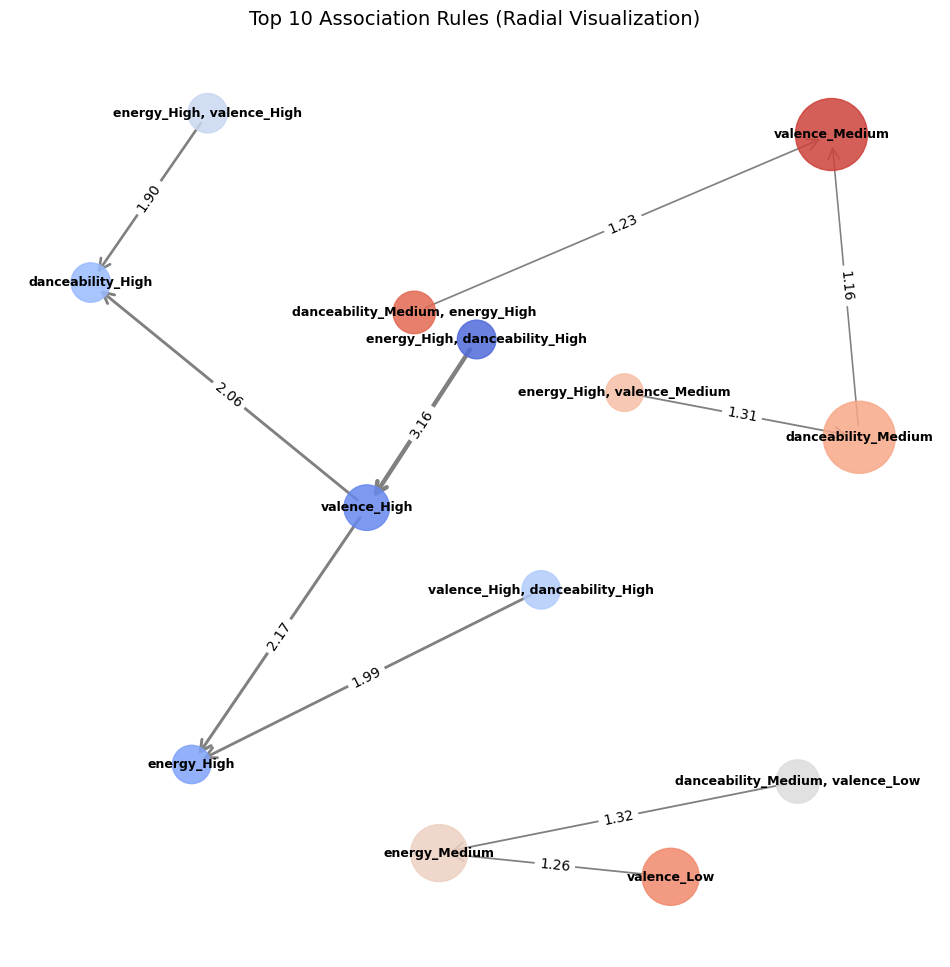

In [32]:
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

# Filter rules for the top 10 based on lift (you can adjust this)
top_rules = sorted_rules.sort_values(by='lift', ascending=False).head(10)

# Create a directed graph
G = nx.DiGraph()

# Add edges with antecedents as start node and consequents as end node
for i, rule in top_rules.iterrows():
    G.add_edge(', '.join(list(rule['antecedents'])),
               ', '.join(list(rule['consequents'])),
               weight=rule['lift'])

# Radial layout (circular node positioning)
pos = nx.spring_layout(G, k=1, seed=42)

# Calculate node sizes based on support, but ensure they match the number of nodes
# Get a list of all nodes in the graph
all_nodes = list(G.nodes())

# Create a dictionary mapping node names to their sizes
node_sizes = {}
for _, rule in top_rules.iterrows():
    antecedent = ', '.join(list(rule['antecedents']))
    consequent = ', '.join(list(rule['consequents']))
    node_sizes[antecedent] = 5000 * rule['support']  # Size for antecedent node
    node_sizes[consequent] = 5000 * rule['support']  # Size for consequent node

# Get the node sizes in the correct order for drawing
node_sizes_list = [node_sizes.get(node, 1000) for node in all_nodes]  # Default size if not in top_rules

# Customize node colors based on confidence
node_color = sns.color_palette("coolwarm", len(G))

# Draw the nodes with proportional sizes
plt.figure(figsize=(12, 12))
nx.draw_networkx_nodes(G, pos, node_color=node_color, node_size=node_sizes_list, alpha=0.85)

# Draw the edges with varying thickness based on lift
edges = nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20,
                               edge_color='grey', width=[G[u][v]['weight'] for u,v in G.edges])

# Draw labels for nodes
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold', font_color='black')

# Add edge labels (showing the lift of each rule)
edge_labels = {(u, v): f"{G[u][v]['weight']:.2f}" for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

# Title and visual adjustments
plt.title('Top 10 Association Rules (Radial Visualization)', fontsize=14)
plt.axis('off')  # Turn off the axis
plt.show()